# **Выпускная квалификационная работа**
### Применение NLP для автоматической обработки и анализа финансовых новостей

Яблонцева Анастасия ПМ22-6

### **Загрузка библиотек**

In [ ]:
pip install pandas datasets scikit-learn matplotlib kagglehub

In [ ]:
!pip install transformers torch -q

In [ ]:
import re
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### **Загрузка и очистка Financial PhraseBank**

Загружаем один из вариантов согласия аннотаторов

In [ ]:
# Загружаем один из вариантов согласия аннотаторов (от большего % к меньшему): 'sentences_allagree', 'sentences_75agree', 'sentences_66agree', 'sentences_50agree'
file_path = "Sentences_AllAgree.txt"

df_hf = pd.read_csv(
    file_path,
    sep='@',
    header=None,
    names=["text", "sentiment"],
    encoding="latin-1",
    engine="python"
)

df_hf.head()

,text,sentiment
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [ ]:
print(df_hf.shape)

(2264, 2)


In [ ]:
df_hf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2264 entries, 0 to 2263
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       2264 non-null   object
 1   sentiment  2264 non-null   object
dtypes: object(2)
memory usage: 35.5+ KB


In [ ]:
df_hf["sentiment"] = df_hf["sentiment"].astype(str).str.strip().str.lower()

# функция очистки текста
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)     # удаление html-тегов
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)     # удаление url
    text = re.sub(r"\s+", " ", text)     # удаление лишних пробелов и переводов строк
    text = text.lower().strip()    # приведение к нижнему регистру
    return text

df_hf["text"] = df_hf["text"].apply(clean_text)
df_hf = df_hf[df_hf["text"].str.len() > 0] # удаление пустых строк
df_hf = df_hf.drop_duplicates(subset=["text", "sentiment"]).reset_index(drop=True) # удаление дубликатов
df_hf["source"] = "financial_phrasebank" # добавление источника

print(df_hf.head())
print(df_hf.shape)

                                                text sentiment  \
0  according to gran , the company has no plans t...   neutral   
1  for the last quarter of 2010 , componenta 's n...  positive   
2  in the third quarter of 2010 , net sales incre...  positive   
3  operating profit rose to eur 13.1 mn from eur ...  positive   
4  operating profit totalled eur 21.1 mn , up fro...  positive   

                 source  
0  financial_phrasebank  
1  financial_phrasebank  
2  financial_phrasebank  
3  financial_phrasebank  
4  financial_phrasebank  
(2259, 3)


In [ ]:
sample_fp = df_hf.sample(6).reset_index(drop=True)

sample_fp_table = sample_fp[["text", "sentiment"]].rename(columns={
    "text": "Текст",
    "sentiment": "Класс"
})

sample_fp_table

,Текст,Класс
0,the total restructuring costs are expected to ...,neutral
1,operating profit rose to eur 13.1 mn from eur ...,positive
2,it will also strengthen ruukki 's offshore bus...,positive
3,"29 september , 2010 finnish waste management a...",positive
4,lithuanian beer makers sold 256.88 million lit...,positive
5,the investments and operational changes enable...,positive


In [ ]:
from IPython.display import display

display(
    sample_fp_table.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
)

Текст,Класс
"the total restructuring costs are expected to be about eur 30mn , of which eur 13.5 mn was booked in december 2008 .",neutral
operating profit rose to eur 13.1 mn from eur 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales .,positive
it will also strengthen ruukki 's offshore business .,positive
"29 september , 2010 finnish waste management and recycling company lassila & tikanoja expands its operations in russia by introducing its recently completed recycling plant in the city of dubna near moscow .",positive
"lithuanian beer makers sold 256.88 million liters of beer in 2005 , a rise of 4.5 per cent from the year-earlier figure of 245.92 million liters .",positive
the investments and operational changes enable additional optimisation of the working hours and thereby further cost savings of some 7 % -9 % .,positive


Проверка распределения классов

In [ ]:
print(df_hf["sentiment"].value_counts())

sentiment
neutral     1386
positive     570
negative     303
Name: count, dtype: int64


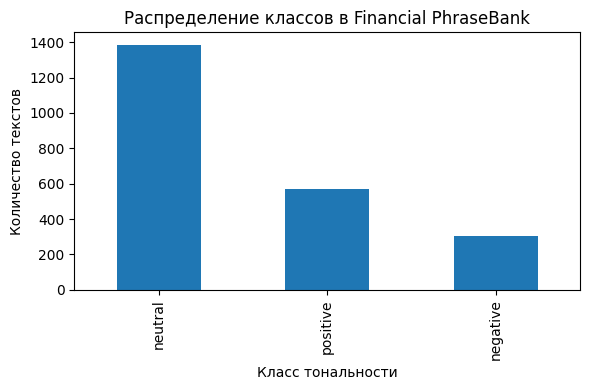

In [ ]:
import matplotlib.pyplot as plt

class_counts = df_hf["sentiment"].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Распределение классов в Financial PhraseBank")
plt.xlabel("Класс тональности")
plt.ylabel("Количество текстов")
plt.tight_layout()
plt.show()

In [ ]:
df_hf["text_length"] = df_hf["text"].apply(lambda x: len(x.split()))
print(df_hf["text_length"].describe())

count    2259.000000
mean       22.424967
std        10.122064
min         2.000000
25%        15.000000
50%        21.000000
75%        28.000000
max        81.000000
Name: text_length, dtype: float64


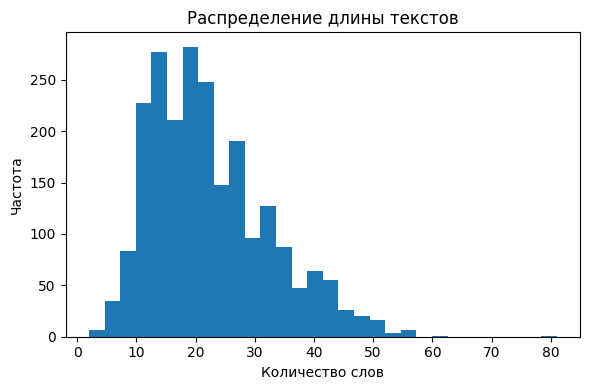

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df_hf["text_length"], bins=30)
plt.title("Распределение длины текстов")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

In [ ]:
df_hf.to_csv("financial_phrasebank_cleaned.csv", index=False, encoding="utf-8")
print("Файл сохранён: financial_phrasebank_cleaned.csv")

Файл сохранён: financial_phrasebank_cleaned.csv


### **Загрузка и очистка Daily News DJIA**

Обработка Daily News for Stock Market Prediction

In [ ]:
df_djia = pd.read_csv("Combined_News_DJIA.csv")
news_columns = [col for col in df_djia.columns if "Top" in col]
df_djia["text"] = df_djia[news_columns].fillna("").agg(" ".join, axis=1)
df_djia = df_djia[["Date", "text", "Label"]]
df_djia.head()

,Date,text,Label
0,2008-08-08,"b""Georgia 'downs two Russian warplanes' as cou...",0
1,2008-08-11,b'Why wont America and Nato help us? If they w...,1
2,2008-08-12,b'Remember that adorable 9-year-old who sang a...,0
3,2008-08-13,b' U.S. refuses Israel weapons to attack Iran:...,0
4,2008-08-14,b'All the experts admit that we should legalis...,1


Переименование столбцов, добавление источника

In [ ]:
df_djia = df_djia.rename(columns={
    "Date": "date",
    "Label": "market_label"
})

df_djia["source"] = "daily_news_djia"

Очистка текста

In [ ]:
df_djia["text"] = df_djia["text"].apply(clean_text)

In [ ]:
df_djia["date"] = pd.to_datetime(df_djia["date"], errors="coerce")
df_djia = df_djia.dropna(subset=["date", "market_label", "text"]).copy()
df_djia = df_djia[df_djia["text"].str.len() > 0]

before_dedup = df_djia.shape[0]
df_djia = df_djia.drop_duplicates(subset=["date", "text", "market_label"]).reset_index(drop=True)
after_dedup = df_djia.shape[0]
print("Размер после очистки:", df_djia.shape)

Размер после очистки: (1989, 4)


Информация о датасете:

In [ ]:
df_djia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1989 entries, 0 to 1988
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1989 non-null   datetime64[ns]
 1   text          1989 non-null   object        
 2   market_label  1989 non-null   int64         
 3   source        1989 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 62.3+ KB


In [ ]:
df_djia.head()

,date,text,market_label,source
0,2008-08-08,"b""georgia 'downs two russian warplanes' as cou...",0,daily_news_djia
1,2008-08-11,b'why wont america and nato help us? if they w...,1,daily_news_djia
2,2008-08-12,b'remember that adorable 9-year-old who sang a...,0,daily_news_djia
3,2008-08-13,b' u.s. refuses israel weapons to attack iran:...,0,daily_news_djia
4,2008-08-14,b'all the experts admit that we should legalis...,1,daily_news_djia


In [ ]:
def decode_text(text):
    text = str(text)

    if text.startswith("b'") or text.startswith('b"'):
        text = text[2:-1]

    return text

df_djia["text"] = df_djia["text"].apply(decode_text)
df_djia.head()

,date,text,market_label,source
0,2008-08-08,georgia 'downs two russian warplanes' as count...,0,daily_news_djia
1,2008-08-11,why wont america and nato help us? if they won...,1,daily_news_djia
2,2008-08-12,remember that adorable 9-year-old who sang at ...,0,daily_news_djia
3,2008-08-13,u.s. refuses israel weapons to attack iran: r...,0,daily_news_djia
4,2008-08-14,all the experts admit that we should legalise ...,1,daily_news_djia


In [ ]:
sample_djia = df_djia.sample(4).reset_index(drop=True)

sample_djia_table = sample_djia[["date", "text", "market_label"]].rename(columns={
    "date": "Дата",
    "text": "Текст",
    "market_label": "Класс"
})

sample_djia_table["Класс"] = sample_djia_table["Класс"].map({
    0: "0 — снижение индекса",
    1: "1 — рост/без изменений"
})

sample_djia_table["Текст"] = sample_djia_table["Текст"].str[:250] + "..."

sample_djia_table

,Дата,Текст,Класс
0,2011-12-15,police shave mohawks off punks at indonesia co...,1 — рост/без изменений
1,2014-12-04,"nasa officially announces manned mars mission,...",0 — снижение индекса
2,2015-06-16,a rising tide does not lift all boats: imf stu...,1 — рост/без изменений
3,2014-07-29,japanese steel workers reveal that they saved ...,0 — снижение индекса


In [ ]:
display(
    sample_djia_table.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
)

Дата,Текст,Класс
2011-12-15 00:00:00,"police shave mohawks off punks at indonesia concert - police in indonesias most conservative province raided a punk-rock concert and detained 65 fans, buzzing off their spiky mohawks and stripping away body piercings because of the perceived threat t...",1 — рост/без изменений
2014-12-04 00:00:00,"nasa officially announces manned mars mission, test launch will begin tomorrow testing orbiter. vatican finds hundreds of millions of euros 'tucked away': cardinal 16 major cruise lines released over a billion gallons of sewage into the ocean in 2014...",0 — снижение индекса
2015-06-16 00:00:00,a rising tide does not lift all boats: imf study shows wealth does not 'trickle-down' as many economists believe. imf recommends countries should concentrate on helping the poorest 20% of citizens. millionaires are expected to control nearly half of ...,1 — рост/без изменений
2014-07-29 00:00:00,"japanese steel workers reveal that they saved their city from a nuclear bombing by burning coal tar to block view of us planes; story was kept secret for 69 years out of respect for nagasaki victims, who were bombed instead russia may leave nuclear t...",0 — снижение индекса



Распределение классов market_label:
market_label
1    1065
0     924
Name: count, dtype: int64


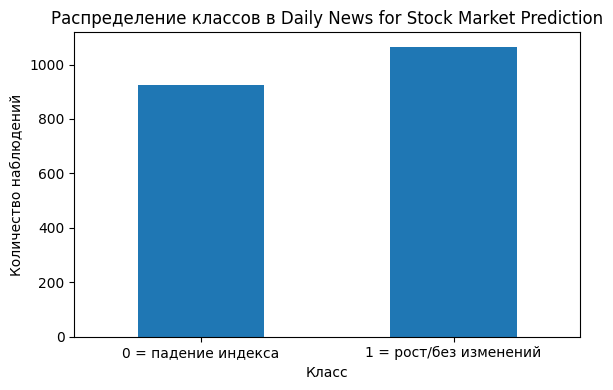

In [ ]:
print("\nРаспределение классов market_label:")
print(df_djia["market_label"].value_counts())

plt.figure(figsize=(6, 4))
df_djia["market_label"].value_counts().sort_index().plot(kind="bar")
plt.title("Распределение классов в Daily News for Stock Market Prediction")
plt.xlabel("Класс")
plt.ylabel("Количество наблюдений")
plt.xticks([0, 1], ["0 = падение индекса", "1 = рост/без изменений"], rotation=0)
plt.tight_layout()
plt.show()


Статистика длины текстов (в словах):
count    1989.000000
mean      442.480644
std        72.265782
min       221.000000
25%       395.000000
50%       443.000000
75%       492.000000
max       720.000000
Name: text_length_words, dtype: float64

Статистика длины текстов (в символах):
count    1989.000000
mean     2775.353947
std       436.596029
min      1467.000000
25%      2485.000000
50%      2782.000000
75%      3069.000000
max      4420.000000
Name: text_length_chars, dtype: float64


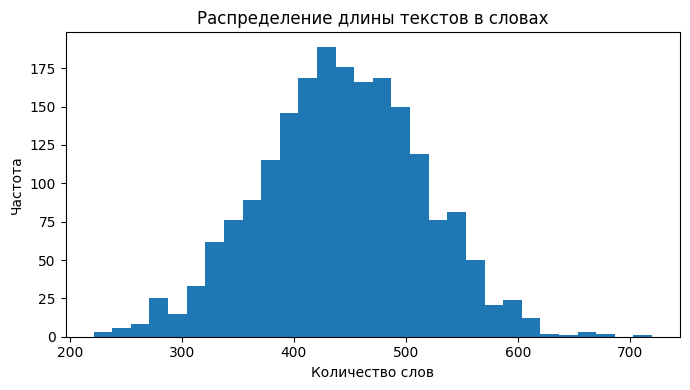

In [ ]:
df_djia["text_length_words"] = df_djia["text"].apply(lambda x: len(x.split()))
df_djia["text_length_chars"] = df_djia["text"].apply(len)

print("\nСтатистика длины текстов (в словах):")
print(df_djia["text_length_words"].describe())

print("\nСтатистика длины текстов (в символах):")
print(df_djia["text_length_chars"].describe())

plt.figure(figsize=(7, 4))
plt.hist(df_djia["text_length_words"], bins=30)
plt.title("Распределение длины текстов в словах")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

Разделение по временным интервалам

In [ ]:
# Согласно описанию датасета:
# Train: 2008-08-08 — 2014-12-31
# Test : 2015-01-02 — 2016-07-01

train_df = df_djia[
    (df_djia["date"] >= "2008-08-08") &
    (df_djia["date"] <= "2014-12-31")
].copy()

test_df = df_djia[
    (df_djia["date"] >= "2015-01-02") &
    (df_djia["date"] <= "2016-07-01")
].copy()

print("\nРазмер обучающей выборки:", train_df.shape)
print("Размер тестовой выборки:", test_df.shape)

print("\nРаспределение классов в train:")
print(train_df["market_label"].value_counts())

print("\nРаспределение классов в test:")
print(test_df["market_label"].value_counts())


Размер обучающей выборки: (1611, 6)
Размер тестовой выборки: (378, 6)

Распределение классов в train:
market_label
1    873
0    738
Name: count, dtype: int64

Распределение классов в test:
market_label
1    192
0    186
Name: count, dtype: int64


In [ ]:
df_djia.to_csv("djia_news_cleaned_full.csv", index=False, encoding="utf-8")
train_df.to_csv("djia_news_train.csv", index=False, encoding="utf-8")
test_df.to_csv("djia_news_test.csv", index=False, encoding="utf-8")

print("\nФайлы сохранены:")
print("- djia_news_cleaned_full.csv")
print("- djia_news_train.csv")
print("- djia_news_test.csv")


Файлы сохранены:
- djia_news_cleaned_full.csv
- djia_news_train.csv
- djia_news_test.csv


### **Обучение моделей анализа текстов**

In [ ]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler

from scipy.sparse import hstack, csr_matrix
import joblib

In [ ]:
df_hf = pd.read_csv("financial_phrasebank_cleaned.csv")
train_df = pd.read_csv("djia_news_train.csv")
test_df = pd.read_csv("djia_news_test.csv")

print(df_hf.head())
print(train_df.head())
print(test_df.head())

                                                text sentiment  \
0  according to gran , the company has no plans t...   neutral   
1  for the last quarter of 2010 , componenta 's n...  positive   
2  in the third quarter of 2010 , net sales incre...  positive   
3  operating profit rose to eur 13.1 mn from eur ...  positive   
4  operating profit totalled eur 21.1 mn , up fro...  positive   

                 source  text_length  
0  financial_phrasebank           25  
1  financial_phrasebank           39  
2  financial_phrasebank           29  
3  financial_phrasebank           24  
4  financial_phrasebank           22  
         date                                               text  \
0  2008-08-08  georgia 'downs two russian warplanes' as count...   
1  2008-08-11  why wont america and nato help us? if they won...   
2  2008-08-12  remember that adorable 9-year-old who sang at ...   
3  2008-08-13   u.s. refuses israel weapons to attack iran: r...   
4  2008-08-14  all the expert

In [ ]:
# признаки и целевая переменная
X_sent = df_hf["text"]
y_sent = df_hf["sentiment"]

X_sent_train, X_sent_test, y_sent_train, y_sent_test = train_test_split(
    X_sent,
    y_sent,
    test_size=0.2,
    random_state=42,
    stratify=y_sent
)

print("Train sentiment:", X_sent_train.shape)
print("Test sentiment:", X_sent_test.shape)
print(y_sent_train.value_counts())
print(y_sent_test.value_counts())

Train sentiment: (1807,)
Test sentiment: (452,)
sentiment
neutral     1109
positive     456
negative     242
Name: count, dtype: int64
sentiment
neutral     277
positive    114
negative     61
Name: count, dtype: int64


Logistic Regression

In [ ]:
pipe_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

pipe_lr.fit(X_sent_train, y_sent_train)
pred_lr = pipe_lr.predict(X_sent_test)

Linear SVM

In [ ]:
pipe_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42
    ))
])

pipe_svm.fit(X_sent_train, y_sent_train)
pred_svm = pipe_svm.predict(X_sent_test)

Naive Bayes

In [ ]:
pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("clf", MultinomialNB())
])

pipe_nb.fit(X_sent_train, y_sent_train)
pred_nb = pipe_nb.predict(X_sent_test)

Random Forest

In [ ]:
pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=7000,
        ngram_range=(1, 1),
        min_df=2
    )),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

pipe_rf.fit(X_sent_train, y_sent_train)
pred_rf = pipe_rf.predict(X_sent_test)

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro"
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted"
    )

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }

results_sentiment = []
results_sentiment.append(evaluate_model(y_sent_test, pred_lr, "Logistic Regression"))
results_sentiment.append(evaluate_model(y_sent_test, pred_svm, "Linear SVM"))
results_sentiment.append(evaluate_model(y_sent_test, pred_nb, "Naive Bayes"))
results_sentiment.append(evaluate_model(y_sent_test, pred_rf, "Random Forest"))

results_sentiment_df = pd.DataFrame(results_sentiment).sort_values(
    by="f1_macro", ascending=False
)

results_sentiment_df

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
1,Linear SVM,0.911504,0.876665,0.888526,0.882298,0.912534,0.911504,0.911883
0,Logistic Regression,0.896018,0.855332,0.872400,0.863399,0.898112,0.896018,0.896820
3,Random Forest,0.876106,0.879030,0.777006,0.815410,0.876267,0.876106,0.868723
2,Naive Bayes,0.809735,0.840840,0.651421,0.672769,0.828554,0.809735,0.787814


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last

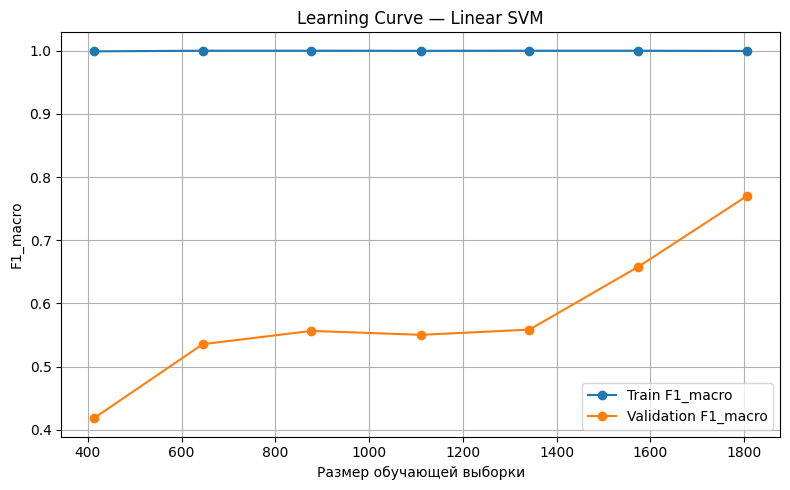

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

# Learning curve для лучшей модели — Linear SVM

train_sizes, train_scores, test_scores = learning_curve(
    pipe_svm,
    X_sent,
    y_sent,
    cv=5,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    random_state=42
)

# Средние значения
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

# График
plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_scores_mean,
    marker="o",
    label="Train F1_macro"
)

plt.plot(
    train_sizes,
    test_scores_mean,
    marker="o",
    label="Validation F1_macro"
)

plt.title("Learning Curve — Linear SVM")
plt.xlabel("Размер обучающей выборки")
plt.ylabel("F1_macro")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Подробный отчёт по лучшей модели

In [ ]:
print("Linear SVM")
print(classification_report(y_sent_test, pred_svm))

Linear SVM
              precision    recall  f1-score   support

    negative       0.82      0.87      0.84        61
     neutral       0.96      0.95      0.95       277
    positive       0.86      0.85      0.85       114

    accuracy                           0.91       452
   macro avg       0.88      0.89      0.88       452
weighted avg       0.91      0.91      0.91       452



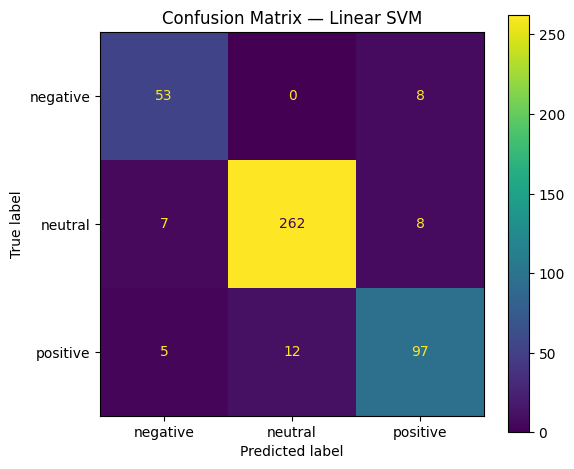

In [ ]:
cm = confusion_matrix(y_sent_test, pred_svm, labels=["negative", "neutral", "positive"])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "neutral", "positive"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)
plt.title("Confusion Matrix — Linear SVM")
plt.tight_layout()
plt.show()

### **Обучение лучшей сентимент-модели на всём PhraseBank**

In [ ]:
best_sent_model = pipe_lr
best_sent_model.fit(df_hf["text"], df_hf["sentiment"])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, min_df=2,
                                 ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [ ]:
train_sent_proba = best_sent_model.predict_proba(train_df["text"])
test_sent_proba = best_sent_model.predict_proba(test_df["text"])

# порядок классов
print(best_sent_model.named_steps["clf"].classes_)

['negative' 'neutral' 'positive']


In [ ]:
classes_ = best_sent_model.named_steps["clf"].classes_

for i, cls in enumerate(classes_):
    train_df[f"sent_{cls}_proba"] = train_sent_proba[:, i]
    test_df[f"sent_{cls}_proba"] = test_sent_proba[:, i]

train_df["predicted_sentiment"] = best_sent_model.predict(train_df["text"])
test_df["predicted_sentiment"] = best_sent_model.predict(test_df["text"])

train_df.head()

,date,text,market_label,source,text_length_words,text_length_chars,sent_negative_proba,sent_neutral_proba,sent_positive_proba,predicted_sentiment
0,2008-08-08,georgia 'downs two russian warplanes' as count...,0,daily_news_djia,374,2360,0.140683,0.721919,0.137399,neutral
1,2008-08-11,why wont america and nato help us? if they won...,1,daily_news_djia,273,1664,0.155080,0.626090,0.218830,neutral
2,2008-08-12,remember that adorable 9-year-old who sang at ...,0,daily_news_djia,351,2155,0.238097,0.616607,0.145295,neutral
3,2008-08-13,u.s. refuses israel weapons to attack iran: r...,0,daily_news_djia,313,2048,0.165532,0.514842,0.319627,neutral
4,2008-08-14,all the experts admit that we should legalise ...,1,daily_news_djia,278,1831,0.196302,0.526472,0.277226,neutral


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
tfidf_market = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    min_df=3,
    max_df=0.9
)

X_train_tfidf = tfidf_market.fit_transform(train_df["text"])
X_test_tfidf = tfidf_market.transform(test_df["text"])

# Добавляем признаки сентимент-анализа (по каждому заголовку)
# Получаем вероятности предсказания для сентимент-модели (Logistic Regression)
train_sent_proba = best_sent_model.predict_proba(train_df["text"])
test_sent_proba = best_sent_model.predict_proba(test_df["text"])
train_df["sentiment_negative_proba"] = train_sent_proba[:, 0]
train_df["sentiment_neutral_proba"] = train_sent_proba[:, 1]
train_df["sentiment_positive_proba"] = train_sent_proba[:, 2]

test_df["sentiment_negative_proba"] = test_sent_proba[:, 0]
test_df["sentiment_neutral_proba"] = test_sent_proba[:, 1]
test_df["sentiment_positive_proba"] = test_sent_proba[:, 2]

train_df["text_length_words"] = train_df["text"].apply(lambda x: len(x.split()))
test_df["text_length_words"] = test_df["text"].apply(lambda x: len(x.split()))

#  Преобразуем признаки в матрицы
fusion_features_train = train_df[[
    "sentiment_negative_proba", "sentiment_neutral_proba", "sentiment_positive_proba",
    "text_length_words"
]].values

fusion_features_test = test_df[[
    "sentiment_negative_proba", "sentiment_neutral_proba", "sentiment_positive_proba",
    "text_length_words"
]].values

# Нормализация
scaler = StandardScaler()
X_train_fusion_num = scaler.fit_transform(fusion_features_train)
X_test_fusion_num = scaler.transform(fusion_features_test)
X_train_fusion = hstack([X_train_tfidf, csr_matrix(X_train_fusion_num)])
X_test_fusion = hstack([X_test_tfidf, csr_matrix(X_test_fusion_num)])

print(X_train_fusion.shape, X_test_fusion.shape)

(1611, 5004) (378, 5004)


In [ ]:
tfidf_market = TfidfVectorizer( #TF-IDF только по DJIA-текстам
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2
)

X_market_train_tfidf = tfidf_market.fit_transform(train_df["text"])
X_market_test_tfidf = tfidf_market.transform(test_df["text"])

y_market_train = train_df["market_label"].values
y_market_test = test_df["market_label"].values

Добавление fusion-признаков

In [ ]:
fusion_features_train = train_df[[
    "sent_negative_proba",
    "sent_neutral_proba",
    "sent_positive_proba",
    "text_length_words",
    "text_length_chars"
]].values

fusion_features_test = test_df[[
    "sent_negative_proba",
    "sent_neutral_proba",
    "sent_positive_proba",
    "text_length_words",
    "text_length_chars"
]].values

X_market_train_fusion = hstack([
    X_market_train_tfidf,
    csr_matrix(fusion_features_train)
])

X_market_test_fusion = hstack([
    X_market_test_tfidf,
    csr_matrix(fusion_features_test)
])

print(X_market_train_fusion.shape, X_market_test_fusion.shape)

(1611, 15005) (378, 15005)


### **Обучение моделей прогнозирования рынка**

Базовая модель: только TF-IDF

In [ ]:
market_lr_base = LogisticRegression(
    max_iter=2000,
    random_state=42
)
market_lr_base.fit(X_market_train_tfidf, y_market_train)
pred_market_base = market_lr_base.predict(X_market_test_tfidf)

Data Fusion модель: TF-IDF + sentiment probabilities

In [ ]:
market_lr_fusion = LogisticRegression(
    max_iter=2000,
    random_state=42
)
market_lr_fusion.fit(X_market_train_fusion, y_market_train)
pred_market_fusion = market_lr_fusion.predict(X_market_test_fusion)

In [ ]:
def evaluate_binary_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary"
    )

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

market_results = []
market_results.append(evaluate_binary_model(y_market_test, pred_market_base, "TF-IDF only"))
market_results.append(evaluate_binary_model(y_market_test, pred_market_fusion, "TF-IDF + Data Fusion"))

market_results_df = pd.DataFrame(market_results)
market_results_df

,model,accuracy,precision,recall,f1
0,TF-IDF only,0.505291,0.507246,0.911458,0.651769
1,TF-IDF + Data Fusion,0.500000,0.504323,0.911458,0.649351


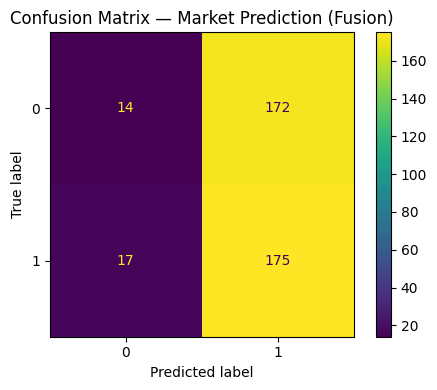

In [ ]:
cm_market = confusion_matrix(y_market_test, pred_market_fusion)
disp_market = ConfusionMatrixDisplay(
    confusion_matrix=cm_market,
    display_labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(5, 4))
disp_market.plot(ax=ax)
plt.title("Confusion Matrix — Market Prediction (Fusion)")
plt.tight_layout()
plt.show()

### **Использование FinBERT**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

finbert_model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(finbert_model_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(finbert_model_name)
finbert_model.to(device)
finbert_model.eval()

print(finbert_model.config.id2label)

Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{0: 'positive', 1: 'negative', 2: 'neutral'}


Получение вероятностей FinBERT

In [ ]:
def get_finbert_probabilities(texts, batch_size=16, max_length=512):
    all_probs = []

    texts = list(texts)

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {key: value.to(device) for key, value in encoded.items()}

        with torch.no_grad():
            outputs = finbert_model(**encoded)
            probs = torch.softmax(outputs.logits, dim=1)

        all_probs.append(probs.cpu().numpy())

    return np.vstack(all_probs)

Оценка FinBERT на Financial PhraseBank

In [ ]:
finbert_probs_hf = get_finbert_probabilities(df_hf["text"], batch_size=16)

label_order = [finbert_model.config.id2label[i].lower() for i in range(finbert_probs_hf.shape[1])]
print("Порядок классов FinBERT:", label_order)

finbert_pred_hf = [label_order[i] for i in np.argmax(finbert_probs_hf, axis=1)]

print(classification_report(df_hf["sentiment"], finbert_pred_hf))

Порядок классов FinBERT: ['positive', 'negative', 'neutral']
              precision    recall  f1-score   support

    negative       0.91      0.98      0.94       303
     neutral       1.00      0.97      0.98      1386
    positive       0.95      0.98      0.96       570

    accuracy                           0.97      2259
   macro avg       0.95      0.98      0.96      2259
weighted avg       0.97      0.97      0.97      2259



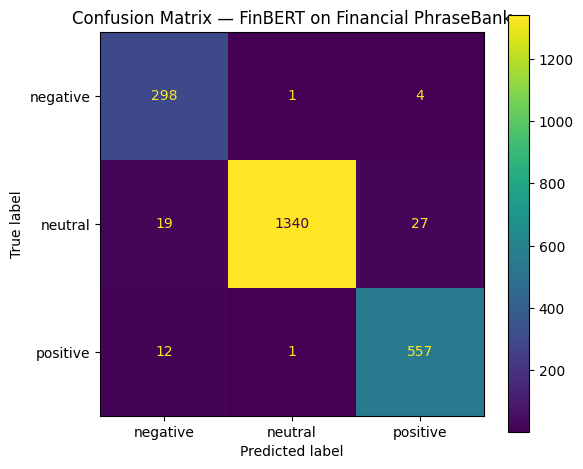

In [ ]:
cm_finbert = confusion_matrix(
    df_hf["sentiment"],
    finbert_pred_hf,
    labels=["negative", "neutral", "positive"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_finbert,
    display_labels=["negative", "neutral", "positive"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)
plt.title("Confusion Matrix — FinBERT on Financial PhraseBank")
plt.tight_layout()
plt.show()

Добавление FinBERT-признаков в DJIA

In [ ]:
train_finbert_probs = get_finbert_probabilities(train_df["text"], batch_size=8)
test_finbert_probs = get_finbert_probabilities(test_df["text"], batch_size=8)

label_order = [finbert_model.config.id2label[i].lower() for i in range(train_finbert_probs.shape[1])]
print("Порядок классов:", label_order)

for i, label in enumerate(label_order):
    train_df[f"finbert_{label}_proba"] = train_finbert_probs[:, i]
    test_df[f"finbert_{label}_proba"] = test_finbert_probs[:, i]

train_df["finbert_sentiment"] = [label_order[i] for i in np.argmax(train_finbert_probs, axis=1)]
test_df["finbert_sentiment"] = [label_order[i] for i in np.argmax(test_finbert_probs, axis=1)]

train_df["finbert_sentiment_score"] = train_df["finbert_positive_proba"] - train_df["finbert_negative_proba"]
test_df["finbert_sentiment_score"] = test_df["finbert_positive_proba"] - test_df["finbert_negative_proba"]

train_df["finbert_confidence"] = train_finbert_probs.max(axis=1)
test_df["finbert_confidence"] = test_finbert_probs.max(axis=1)

Порядок классов: ['positive', 'negative', 'neutral']


TF-IDF + FinBERT Fusion

In [ ]:
train_df["text_length_words"] = train_df["text"].apply(lambda x: len(str(x).split()))
test_df["text_length_words"] = test_df["text"].apply(lambda x: len(str(x).split()))

train_df["text_length_chars"] = train_df["text"].apply(lambda x: len(str(x)))
test_df["text_length_chars"] = test_df["text"].apply(lambda x: len(str(x)))

tfidf_market = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = tfidf_market.fit_transform(train_df["text"])
X_test_tfidf = tfidf_market.transform(test_df["text"])

y_train = train_df["market_label"].values
y_test = test_df["market_label"].values

In [ ]:
fusion_cols = [
    "finbert_negative_proba",
    "finbert_neutral_proba",
    "finbert_positive_proba",
    "finbert_sentiment_score",
    "finbert_confidence",
    "text_length_words",
    "text_length_chars"
]

scaler = StandardScaler()

X_train_num = scaler.fit_transform(train_df[fusion_cols])
X_test_num = scaler.transform(test_df[fusion_cols])

X_train_finbert_fusion = hstack([
    X_train_tfidf,
    csr_matrix(X_train_num)
])

X_test_finbert_fusion = hstack([
    X_test_tfidf,
    csr_matrix(X_test_num)
])

print(X_train_finbert_fusion.shape)
print(X_test_finbert_fusion.shape)

(1611, 15007)
(378, 15007)


Обучение моделей TF-IDF и TF-IDF + FinBERT

In [ ]:
market_lr_base = LogisticRegression(
    max_iter=3000,
    random_state=42
)

market_lr_base.fit(X_train_tfidf, y_train)
pred_base = market_lr_base.predict(X_test_tfidf)

In [ ]:
market_lr_finbert_fusion = LogisticRegression(
    max_iter=3000,
    random_state=42
)

market_lr_finbert_fusion.fit(X_train_finbert_fusion, y_train)
pred_finbert_fusion = market_lr_finbert_fusion.predict(X_test_finbert_fusion)

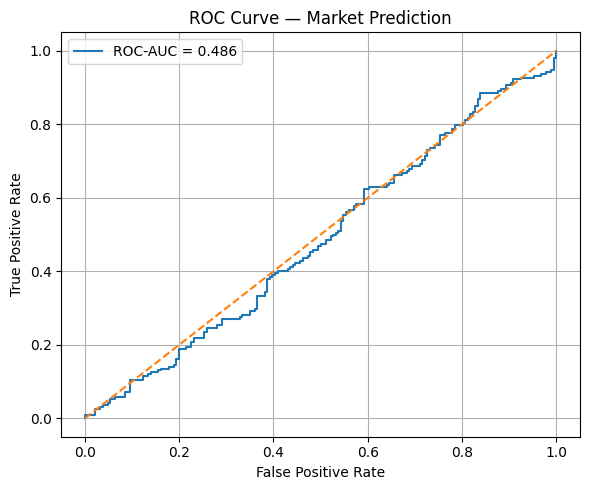

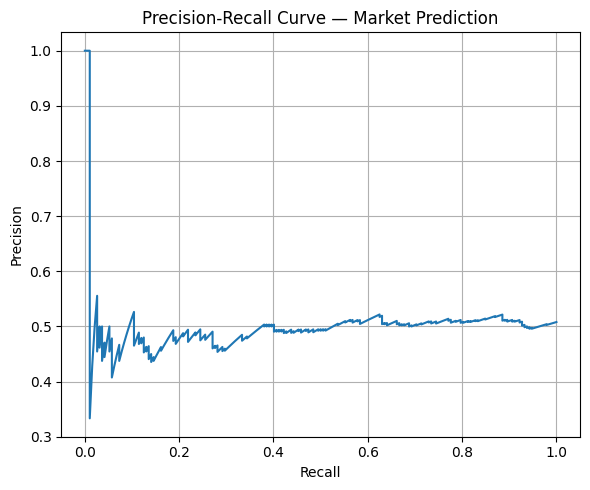

In [ ]:
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve
)

# Вероятности положительного класса
y_probs = market_lr_finbert_fusion.predict_proba(
    X_test_finbert_fusion
)[:, 1]

# ROC CURVE
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Market Prediction")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# PR CURVE
precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(6, 5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Market Prediction")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def evaluate_binary_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f1_macro": f1_macro
    }

market_results = []

market_results.append(
    evaluate_binary_model(y_test, pred_base, "TF-IDF only")
)

market_results.append(
    evaluate_binary_model(y_test, pred_finbert_fusion, "TF-IDF + FinBERT Data Fusion")
)

market_results_df = pd.DataFrame(market_results)
market_results_df

,model,accuracy,precision,recall,f1,f1_macro
0,TF-IDF only,0.515873,0.513433,0.895833,0.652751,0.426812
1,TF-IDF + FinBERT Data Fusion,0.523810,0.518634,0.869792,0.649805,0.453002


ДОПОЛНИТЕЛЬНЫЕ АГРЕГИРОВАННЫЕ ПРИЗНАКИ ТОНАЛЬНОСТИ ПО ДНЮ

In [ ]:
df_raw = pd.read_csv("Combined_News_DJIA.csv")
news_columns = [col for col in df_raw.columns if "Top" in col]

df_long = df_raw.melt(
    id_vars=["Date", "Label"],
    value_vars=news_columns,
    var_name="news_position",
    value_name="headline"
)

df_long = df_long.rename(columns={
    "Date": "date",
    "Label": "market_label"
})

df_long["date"] = pd.to_datetime(df_long["date"], errors="coerce")

df_long = df_long.dropna(subset=["date", "headline"]).copy()

df_long["headline"] = df_long["headline"].apply(clean_text)
df_long["headline"] = df_long["headline"].apply(decode_text)
df_long = df_long[df_long["headline"].str.len() > 0].copy()

print(df_long.head())
print(df_long.shape)

        date  market_label news_position  \
0 2008-08-08             0          Top1   
1 2008-08-11             1          Top1   
2 2008-08-12             0          Top1   
3 2008-08-13             0          Top1   
4 2008-08-14             1          Top1   

                                            headline  
0  georgia 'downs two russian warplanes' as count...  
1  why wont america and nato help us? if they won...  
2  remember that adorable 9-year-old who sang at ...  
3   u.s. refuses israel weapons to attack iran: r...  
4  all the experts admit that we should legalise ...  
(49718, 4)


Получаем вероятности FinBERT для каждого отдельного заголовка

In [ ]:
headline_probs = get_finbert_probabilities(df_long["headline"],batch_size=16)

label_order = [finbert_model.config.id2label[i].lower() for i in range(headline_probs.shape[1])]
print("Порядок классов FinBERT:", label_order)

for i, label in enumerate(label_order):
    df_long[f"headline_finbert_{label}_proba"] = headline_probs[:, i]

df_long["headline_finbert_sentiment"] = [label_order[i] for i in np.argmax(headline_probs, axis=1)]
df_long["headline_finbert_score"] = (df_long["headline_finbert_positive_proba"] - df_long["headline_finbert_negative_proba"])
df_long["headline_finbert_confidence"] = headline_probs.max(axis=1)
df_long["is_positive_headline"] = (df_long["headline_finbert_sentiment"] == "positive").astype(int)
df_long["is_negative_headline"] = (df_long["headline_finbert_sentiment"] == "negative").astype(int)
df_long.head()

Порядок классов FinBERT: ['positive', 'negative', 'neutral']


,date,market_label,news_position,headline,headline_finbert_positive_proba,headline_finbert_negative_proba,headline_finbert_neutral_proba,headline_finbert_sentiment,headline_finbert_score,headline_finbert_confidence,is_positive_headline,is_negative_headline
0,2008-08-08,0,Top1,georgia 'downs two russian warplanes' as count...,0.473203,0.159633,0.367164,positive,0.313569,0.473203,1,0
1,2008-08-11,1,Top1,why wont america and nato help us? if they won...,0.071691,0.076321,0.851987,neutral,-0.004630,0.851987,0,0
2,2008-08-12,0,Top1,remember that adorable 9-year-old who sang at ...,0.039779,0.165592,0.794629,neutral,-0.125813,0.794629,0,0
3,2008-08-13,0,Top1,u.s. refuses israel weapons to attack iran: r...,0.030181,0.079618,0.890201,neutral,-0.049437,0.890201,0,0
4,2008-08-14,1,Top1,all the experts admit that we should legalise ...,0.373662,0.013805,0.612533,neutral,0.359857,0.612533,0,0


Агрегируем признаки по дню

In [ ]:
daily_sentiment_features = df_long.groupby("date").agg(
    day_finbert_positive_mean=("headline_finbert_positive_proba", "mean"),
    day_finbert_negative_mean=("headline_finbert_negative_proba", "mean"),
    day_finbert_neutral_mean=("headline_finbert_neutral_proba", "mean"),
    day_sentiment_score_mean=("headline_finbert_score", "mean"),
    day_finbert_confidence_max=("headline_finbert_confidence", "max"),
    day_finbert_confidence_mean=("headline_finbert_confidence", "mean"),
    positive_headline_share=("is_positive_headline", "mean"),
    negative_headline_share=("is_negative_headline", "mean"),
    positive_headline_count=("is_positive_headline", "sum"),
    negative_headline_count=("is_negative_headline", "sum")
).reset_index()

daily_sentiment_features.head()

,date,day_finbert_positive_mean,day_finbert_negative_mean,day_finbert_neutral_mean,day_sentiment_score_mean,day_finbert_confidence_max,day_finbert_confidence_mean,positive_headline_share,negative_headline_share,positive_headline_count,negative_headline_count
0,2008-08-08,0.067307,0.518904,0.413788,-0.451597,0.923312,0.738477,0.04,0.64,1,16
1,2008-08-11,0.165226,0.355888,0.478886,-0.190661,0.943866,0.775767,0.12,0.32,3,8
2,2008-08-12,0.054718,0.277398,0.667884,-0.222680,0.967509,0.804383,0.00,0.20,0,5
3,2008-08-13,0.080011,0.399029,0.520960,-0.319017,0.919955,0.730315,0.00,0.36,0,9
4,2008-08-14,0.115661,0.382844,0.501495,-0.267183,0.957547,0.776437,0.04,0.44,1,11


In [ ]:
train_df["date"] = pd.to_datetime(train_df["date"], errors="coerce")
test_df["date"] = pd.to_datetime(test_df["date"], errors="coerce")
train_df = train_df.merge(daily_sentiment_features, on="date", how="left")
test_df = test_df.merge(daily_sentiment_features, on="date", how="left")

agg_cols = [
    "day_finbert_positive_mean",
    "day_finbert_negative_mean",
    "day_finbert_neutral_mean",
    "day_sentiment_score_mean",
    "day_finbert_confidence_max",
    "day_finbert_confidence_mean",
    "positive_headline_share",
    "negative_headline_share",
    "positive_headline_count",
    "negative_headline_count"
]

train_df[agg_cols] = train_df[agg_cols].fillna(0)
test_df[agg_cols] = test_df[agg_cols].fillna(0)

print(train_df[agg_cols].head())
print(test_df[agg_cols].head())

   day_finbert_positive_mean  day_finbert_negative_mean  \
0                   0.067307                   0.518904   
1                   0.165226                   0.355888   
2                   0.054718                   0.277398   
3                   0.080011                   0.399029   
4                   0.115661                   0.382844   

   day_finbert_neutral_mean  day_sentiment_score_mean  \
0                  0.413788                 -0.451597   
1                  0.478886                 -0.190661   
2                  0.667884                 -0.222680   
3                  0.520960                 -0.319017   
4                  0.501495                 -0.267183   

   day_finbert_confidence_max  day_finbert_confidence_mean  \
0                    0.923312                     0.738477   
1                    0.943866                     0.775767   
2                    0.967509                     0.804383   
3                    0.919955                     0.73

In [ ]:
fusion_cols = [
    "finbert_negative_proba",
    "finbert_neutral_proba",
    "finbert_positive_proba",
    "finbert_sentiment_score",
    "finbert_confidence",
    "text_length_words",
    "text_length_chars",

    "day_finbert_positive_mean",
    "day_finbert_negative_mean",
    "day_finbert_neutral_mean",
    "day_sentiment_score_mean",
    "day_finbert_confidence_max",
    "day_finbert_confidence_mean",
    "positive_headline_share",
    "negative_headline_share",
    "positive_headline_count",
    "negative_headline_count"
]

In [ ]:
print(train_df.columns)

Index(['date', 'text', 'market_label', 'source', 'text_length_words',
       'text_length_chars', 'sent_negative_proba', 'sent_neutral_proba',
       'sent_positive_proba', 'predicted_sentiment',
       'sentiment_negative_proba', 'sentiment_neutral_proba',
       'sentiment_positive_proba', 'day_finbert_positive_mean_x',
       'day_finbert_negative_mean_x', 'day_finbert_neutral_mean_x',
       'day_sentiment_score_mean_x', 'day_finbert_confidence_max_x',
       'day_finbert_confidence_mean_x', 'positive_headline_share_x',
       'negative_headline_share_x', 'positive_headline_count_x',
       'negative_headline_count_x', 'finbert_positive_proba',
       'finbert_negative_proba', 'finbert_neutral_proba', 'finbert_sentiment',
       'finbert_sentiment_score', 'finbert_confidence',
       'day_finbert_positive_mean_y', 'day_finbert_negative_mean_y',
       'day_finbert_neutral_mean_y', 'day_sentiment_score_mean_y',
       'day_finbert_confidence_max_y', 'day_finbert_confidence_mean_y',


In [ ]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(train_df[fusion_cols])
X_test_num = scaler.transform(test_df[fusion_cols])

X_train_finbert_fusion = hstack([
    X_train_tfidf,
    csr_matrix(X_train_num)
])

X_test_finbert_fusion = hstack([
    X_test_tfidf,
    csr_matrix(X_test_num)
])

market_lr_finbert_fusion = LogisticRegression(
    max_iter=3000,
    random_state=42
)

market_lr_finbert_fusion.fit(X_train_finbert_fusion, y_train)
pred_finbert_fusion = market_lr_finbert_fusion.predict(X_test_finbert_fusion)

market_results = []

market_results.append(
    evaluate_binary_model(y_test, pred_base, "TF-IDF only")
)

market_results.append(
    evaluate_binary_model(y_test, pred_finbert_fusion, "TF-IDF + Aggregated FinBERT Data Fusion")
)

market_results_df = pd.DataFrame(market_results)
market_results_df

,model,accuracy,precision,recall,f1,f1_macro
0,TF-IDF only,0.515873,0.513433,0.895833,0.652751,0.426812
1,TF-IDF + Aggregated FinBERT Data Fusion,0.489418,0.498423,0.822917,0.620825,0.419724


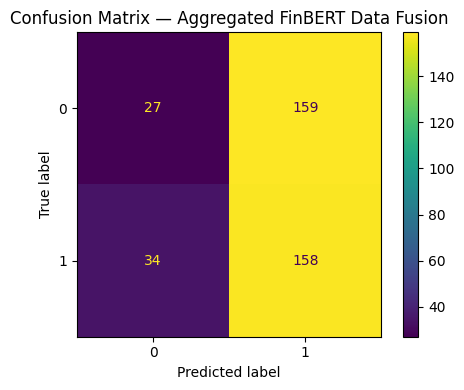

In [ ]:
cm_market_finbert = confusion_matrix(y_test, pred_finbert_fusion)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_market_finbert,
    display_labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax)
plt.title("Confusion Matrix — Aggregated FinBERT Data Fusion")
plt.tight_layout()
plt.show()

### **Применение на новых новостях**

In [ ]:
new_texts = [
    "Apple reports record quarterly revenue and strong iPhone sales",
    "Global markets fall as inflation fears increase",
    "Company announces restructuring plan with no major financial impact",
    "Tesla stock drops after weaker than expected earnings",
    "Central bank signals possible interest rate cuts"
]

new_texts_clean = [clean_text(t) for t in new_texts]
new_probs = get_finbert_probabilities(new_texts_clean, batch_size=4)
label_order = [finbert_model.config.id2label[i].lower() for i in range(new_probs.shape[1])]

results = pd.DataFrame({
    "text": new_texts,
    "predicted_sentiment": [label_order[i] for i in np.argmax(new_probs, axis=1)],
    "positive_proba": new_probs[:, label_order.index("positive")],
    "negative_proba": new_probs[:, label_order.index("negative")],
    "neutral_proba": new_probs[:, label_order.index("neutral")]
})

results["sentiment_score"] = results["positive_proba"] - results["negative_proba"]

print(results)

                                                text predicted_sentiment  \
0  Apple reports record quarterly revenue and str...            positive   
1    Global markets fall as inflation fears increase            negative   
2  Company announces restructuring plan with no m...             neutral   
3  Tesla stock drops after weaker than expected e...            negative   
4   Central bank signals possible interest rate cuts             neutral   

   positive_proba  negative_proba  neutral_proba  sentiment_score  
0        0.950211        0.024027       0.025762         0.926184  
1        0.009746        0.964088       0.026166        -0.954342  
2        0.026277        0.375630       0.598093        -0.349353  
3        0.016188        0.950185       0.033627        -0.933998  
4        0.319403        0.305607       0.374990         0.013796  


In [ ]:
from IPython.display import display
display(results.round(3))

,text,predicted_sentiment,positive_proba,negative_proba,neutral_proba,sentiment_score
0,Apple reports record quarterly revenue and str...,positive,0.950,0.024,0.026,0.926
1,Global markets fall as inflation fears increase,negative,0.010,0.964,0.026,-0.954
2,Company announces restructuring plan with no m...,neutral,0.026,0.376,0.598,-0.349
3,Tesla stock drops after weaker than expected e...,negative,0.016,0.950,0.034,-0.934
4,Central bank signals possible interest rate cuts,neutral,0.319,0.306,0.375,0.014


In [ ]:
from IPython.display import display

results_pretty = results.rename(columns={
    "text": "Новость",
    "predicted_sentiment": "Тональность",
    "positive_proba": "P(positive)",
    "negative_proba": "P(negative)",
    "neutral_proba": "P(neutral)",
    "sentiment_score": "Sentiment score"
})

results_pretty["Новость"] = results_pretty["Новость"].str[:60] + "..."

styled = results_pretty.style\
    .background_gradient(cmap="RdYlGn", subset=["Sentiment score"])\
    .format({
        "P(positive)": "{:.3f}",
        "P(negative)": "{:.3f}",
        "P(neutral)": "{:.3f}",
        "Sentiment score": "{:.3f}"
    })

display(styled)

,Новость,Тональность,P(positive),P(negative),P(neutral),Sentiment score
0,Apple reports record quarterly revenue and strong iPhone sal...,positive,0.950,0.024,0.026,0.926
1,Global markets fall as inflation fears increase...,negative,0.010,0.964,0.026,-0.954
2,Company announces restructuring plan with no major financial...,neutral,0.026,0.376,0.598,-0.349
3,Tesla stock drops after weaker than expected earnings...,negative,0.016,0.950,0.034,-0.934
4,Central bank signals possible interest rate cuts...,neutral,0.319,0.306,0.375,0.014


In [ ]:
base_fusion_cols = [
    "finbert_negative_proba",
    "finbert_neutral_proba",
    "finbert_positive_proba",
    "finbert_sentiment_score",
    "finbert_confidence",
    "text_length_words",
    "text_length_chars"
]

scaler_base = StandardScaler()

X_train_base_num = scaler_base.fit_transform(train_df[base_fusion_cols])
X_test_base_num = scaler_base.transform(test_df[base_fusion_cols])

X_train_base_fusion = hstack([
    X_train_tfidf,
    csr_matrix(X_train_base_num)
])

X_test_base_fusion = hstack([
    X_test_tfidf,
    csr_matrix(X_test_base_num)
])

market_lr_base_fusion = LogisticRegression(
    max_iter=3000,
    random_state=42
)

market_lr_base_fusion.fit(X_train_base_fusion, y_train)

pred_base_fusion = market_lr_base_fusion.predict(X_test_base_fusion)

evaluate_binary_model(
    y_test,
    pred_base_fusion,
    "TF-IDF + FinBERT Data Fusion"
)

{'model': 'TF-IDF + FinBERT Data Fusion',
 'accuracy': 0.5238095238095238,
 'precision': 0.5186335403726708,
 'recall': 0.8697916666666666,
 'f1': 0.6498054474708171,
 'f1_macro': 0.45300189728912754}

In [ ]:
combined_text = " ".join(new_texts_clean)

X_new_tfidf = tfidf_market.transform([combined_text])

new_day_probs = get_finbert_probabilities([combined_text])

new_features = np.array([
    new_day_probs[0][label_order.index("negative")],
    new_day_probs[0][label_order.index("neutral")],
    new_day_probs[0][label_order.index("positive")],
    new_day_probs[0][label_order.index("positive")] - new_day_probs[0][label_order.index("negative")],
    new_day_probs.max(),
    len(combined_text.split()),
    len(combined_text)
]).reshape(1, -1)

new_features_scaled = scaler_base.transform(new_features)

X_new = hstack([
    X_new_tfidf,
    csr_matrix(new_features_scaled)
])

pred_market = market_lr_base_fusion.predict(X_new)[0]

print(
    "Прогноз движения индекса:",
    "Рост/без изменений" if pred_market == 1 else "Падение"
)

Прогноз движения индекса: Рост/без изменений


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
